In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Load data
df = pd.read_csv("data/raw/telco_churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# ── Cell 2: TotalCharges — convert blank strings to NaN (do NOT impute yet) ──
# WHY: TotalCharges contains " " (space) strings for 11 new customers (tenure=0).
# pd.to_numeric with errors='coerce' converts blanks to NaN cleanly.
# We do NOT fill here — imputation must happen AFTER the train/test split
# so the imputer learns only from training data (zero leakage rule, M06).

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_nan = df["TotalCharges"].isna().sum()
print(f"TotalCharges NaN count: {n_nan}")
print("These rows have tenure=0 (new customers — no charges yet):")
print(df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])
print("\n✓ NaN preserved — imputation deferred to post-split Cell 2b.")

TotalCharges NaN count: 11
These rows have tenure=0 (new customers — no charges yet):
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

✓ NaN preserved — imputation deferred to post-split Cell 2b.


In [3]:
# ── Cell 2b: Train/Test Split + Leak-proof Imputation ────────────────────────
# This cell must run BEFORE any imputation or correlation analysis.
# Splitting first is the non-negotiable M06 rule.

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
import numpy as np

# Step A: Encode target (needed before stratified split)
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

# Step B: Drop uninformative columns
#   customerID  — unique identifier, no predictive value, would cause overfitting
#   Churn       — original string target; replaced by Churn_binary
df_model = df.drop(columns=["customerID", "Churn"])

# Step C: Stratified 80/20 split
# WHY stratify=y: churn rate is 26.5% — without stratification, a random split
# could give 23% in one fold and 30% in another by chance. Stratification
# guarantees both splits have the same churn rate, making evaluation honest.
X = df_model.drop(columns=["Churn_binary"])
y = df_model["Churn_binary"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,    # reproducible — any team member gets identical splits
    stratify=y
)

print(f"Train: {X_train_raw.shape[0]:,} rows | churn rate: {y_train.mean():.3f}")
print(f"Test:  {X_test_raw.shape[0]:,} rows | churn rate: {y_test.mean():.3f}")
print("Churn rates should match ✓")

# Step D: Impute TotalCharges using KNNImputer — fit on TRAIN only
# WHY KNN over fillna(0):
#   - fillna(0) is wrong: a customer with tenure=0 has MonthlyCharges > 0,
#     so their true TotalCharges ≈ MonthlyCharges × 1 month, not 0.
#   - KNNImputer finds the k=5 most similar customers (by tenure and
#     MonthlyCharges) and uses their TotalCharges as the estimate.
#   - The imputer is fitted ONLY on X_train_raw — test data's values
#     never influence how missing values are filled.
# WHY only on numeric columns:
#   KNNImputer requires numeric input. Categoricals are encoded in Phase 2.
#   We isolate the numeric subset for imputation now.

numeric_cols_for_impute = ["tenure", "MonthlyCharges", "TotalCharges"]

imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train_raw[numeric_cols_for_impute])   # learn from train only

# Transform both splits with the same fitted imputer
X_train_raw[numeric_cols_for_impute] = imputer.transform(
    X_train_raw[numeric_cols_for_impute]
)
X_test_raw[numeric_cols_for_impute] = imputer.transform(
    X_test_raw[numeric_cols_for_impute]
)

print(f"\nAfter KNN imputation:")
print(f"  Train NaN in TotalCharges: {X_train_raw['TotalCharges'].isna().sum()}")
print(f"  Test  NaN in TotalCharges: {X_test_raw['TotalCharges'].isna().sum()}")
print("✓ Imputation complete — zero leakage confirmed")

Train: 5,634 rows | churn rate: 0.265
Test:  1,409 rows | churn rate: 0.265
Churn rates should match ✓

After KNN imputation:
  Train NaN in TotalCharges: 0
  Test  NaN in TotalCharges: 0
✓ Imputation complete — zero leakage confirmed


In [4]:
# Binary encode the target
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

# Verify
print(df["Churn_binary"].value_counts())
print(f"\nChurn rate: {df['Churn_binary'].mean():.3f}")

Churn_binary
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 0.265


In [5]:
# Separate columns by type
numeric_cols = df.select_dtypes(include="number").columns.tolist()
object_cols  = df.select_dtypes(include="object").columns.tolist()

# Remove ID and original target from lists
numeric_cols = [c for c in numeric_cols if c not in ["Churn_binary"]]
object_cols  = [c for c in object_cols  if c not in ["customerID", "Churn"]]

print("NUMERIC COLUMNS:", numeric_cols)
print(f"\nCATEGORICAL COLUMNS ({len(object_cols)}):", object_cols)

# Cardinality of categoricals
for col in object_cols:
    print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique().tolist()}")

NUMERIC COLUMNS: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

CATEGORICAL COLUMNS (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
  gender: 2 unique values → ['Female', 'Male']
  Partner: 2 unique values → ['Yes', 'No']
  Dependents: 2 unique values → ['No', 'Yes']
  PhoneService: 2 unique values → ['No', 'Yes']
  MultipleLines: 3 unique values → ['No phone service', 'No', 'Yes']
  InternetService: 3 unique values → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: 3 unique values → ['No', 'Yes', 'No internet service']
  OnlineBackup: 3 unique values → ['Yes', 'No', 'No internet service']
  DeviceProtection: 3 unique values → ['No', 'Yes', 'No internet service']
  TechSupport: 3 unique values → ['No', 'Yes', 'No internet service']
  StreamingTV: 3 unique values → ['No', 'Yes',

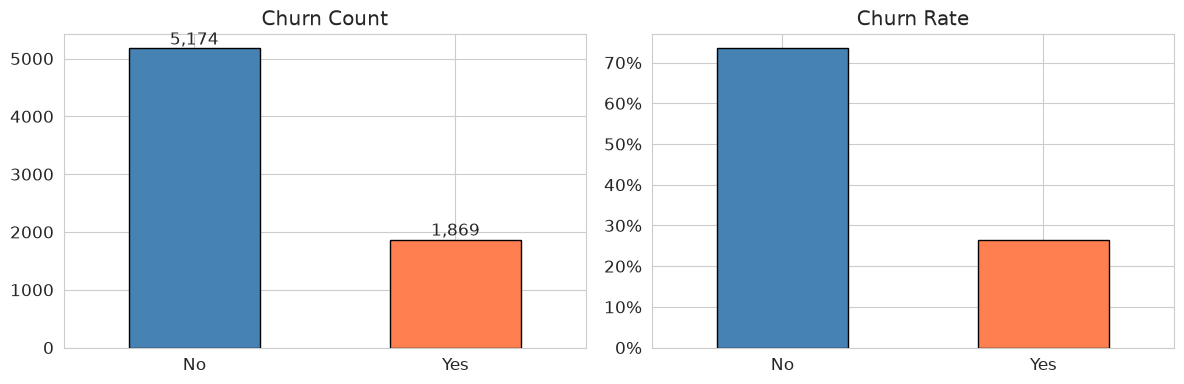

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"],
                                 edgecolor="black")
axes[0].set_title("Churn Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')

# Percentage
df["Churn"].value_counts(normalize=True).plot(kind="bar", ax=axes[1],
                                               color=["steelblue", "coral"],
                                               edgecolor="black")
axes[1].set_title("Churn Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig("reports/figures/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

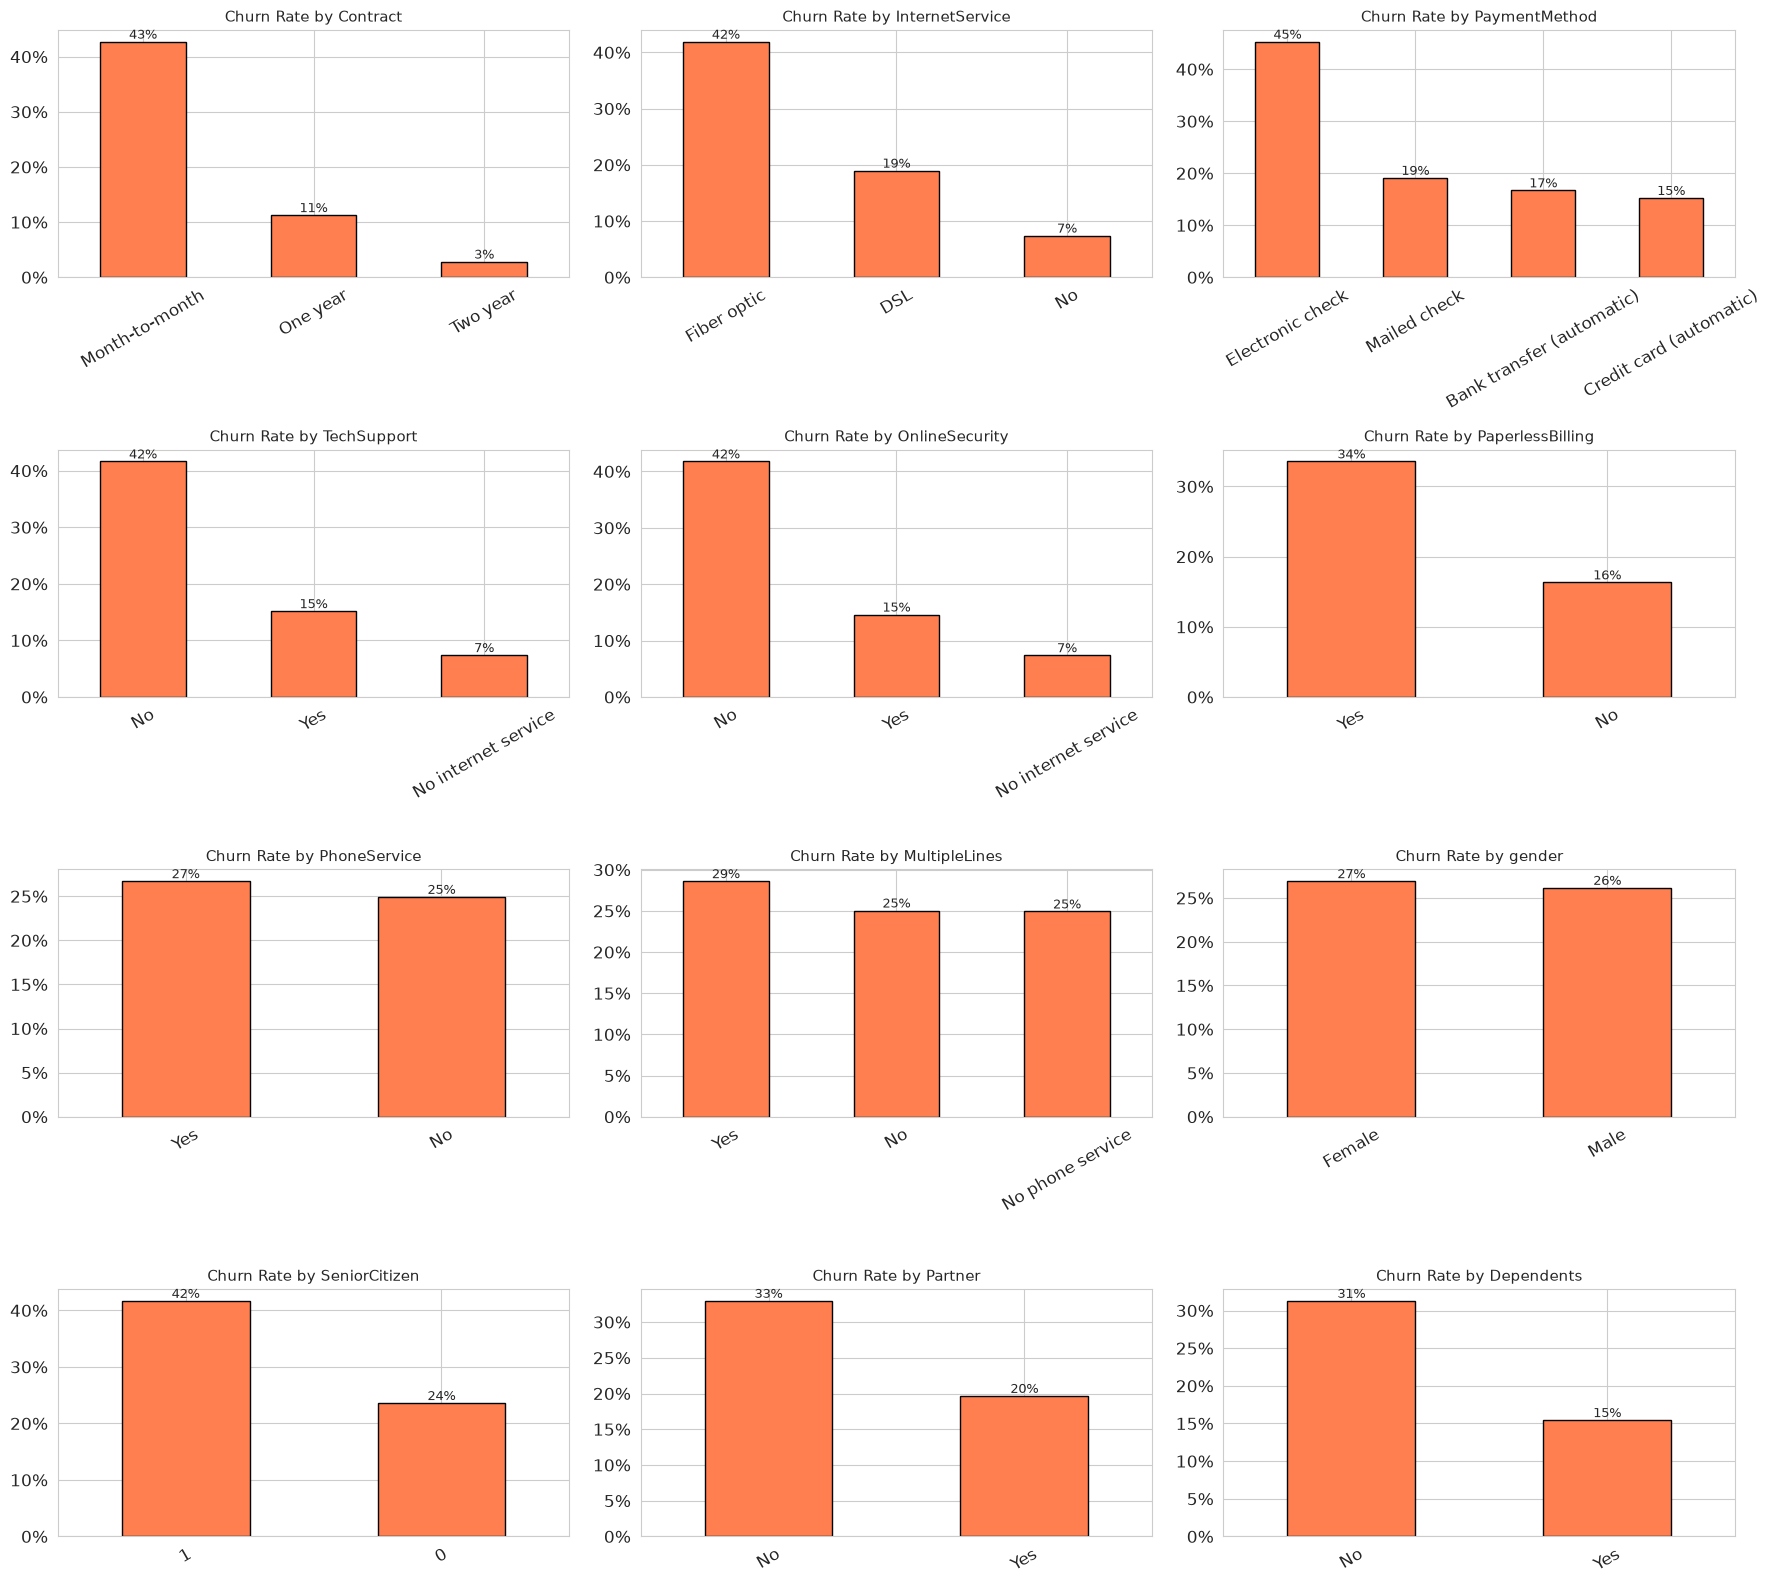

In [7]:
# Features known from domain knowledge to matter
cat_features = ["Contract", "InternetService", "PaymentMethod",
                "TechSupport", "OnlineSecurity", "PaperlessBilling",
                "PhoneService", "MultipleLines", "gender", "SeniorCitizen",
                "Partner", "Dependents"]

n_cols = 3
n_rows = (len(cat_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_by_cat = df.groupby(col)["Churn_binary"].mean().sort_values(ascending=False)
    bars = churn_by_cat.plot(kind="bar", ax=axes[i], color="coral", edgecolor="black")
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    # Add value labels
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.0%}',
                          (p.get_x() + p.get_width()/2, p.get_height()),
                          ha='center', va='bottom', fontsize=9)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("reports/figures/02_churn_by_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

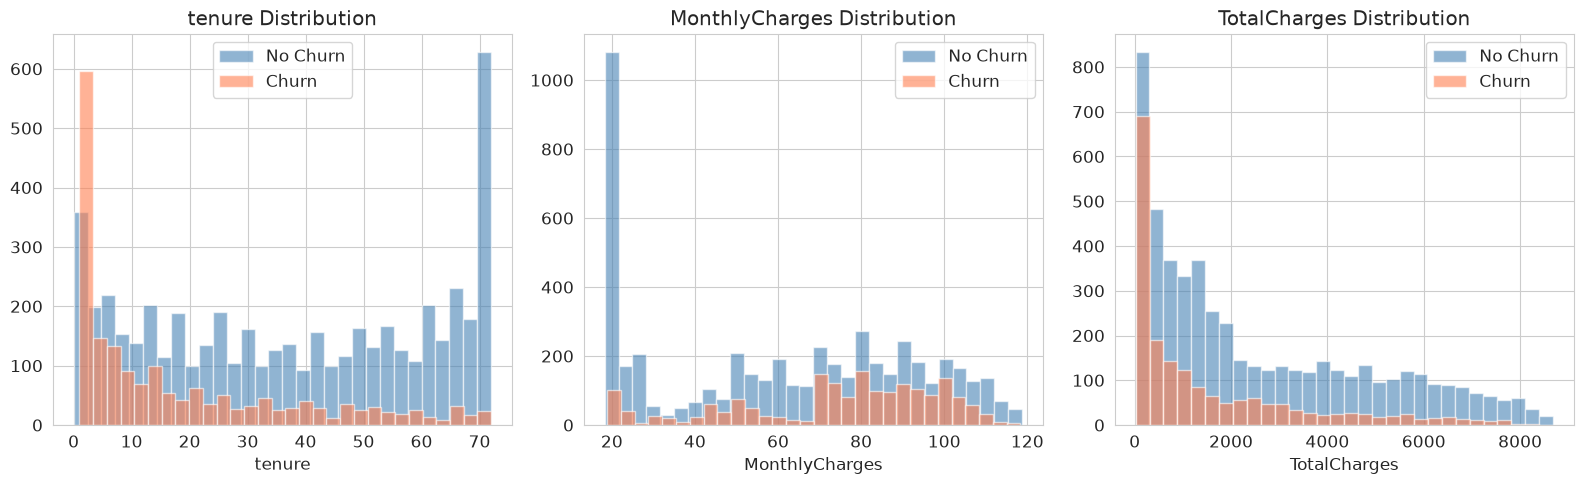

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    churned     = df[df["Churn_binary"] == 1][col]
    not_churned = df[df["Churn_binary"] == 0][col]

    ax.hist(not_churned, bins=30, alpha=0.6, label="No Churn", color="steelblue")
    ax.hist(churned,     bins=30, alpha=0.6, label="Churn",    color="coral")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.savefig("reports/figures/03_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

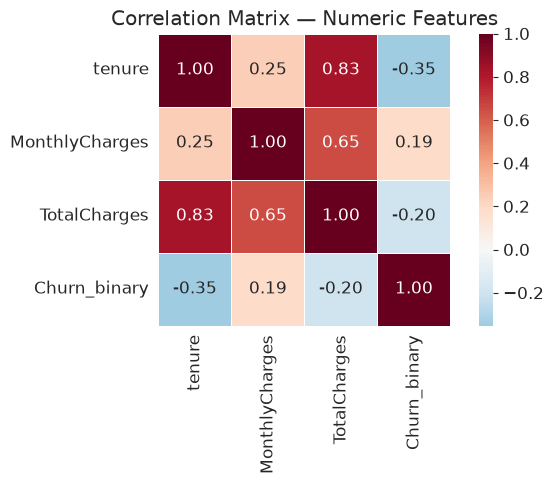

HIGH-CORRELATION PAIRS (r ≥ 0.70):
  tenure × TotalCharges: r = 0.826

VIF SCORES (computed on training data only):
  tenure: VIF = 5.93 ⚠ HIGH
  MonthlyCharges: VIF = 3.23
  TotalCharges: VIF = 9.68 ⚠ HIGH

VIF AFTER MITIGATION:
  tenure: VIF = 1.07 ✓
  MonthlyCharges: VIF = 135.38 ⚠ HIGH
  charges_per_month: VIF = 135.3 ⚠ HIGH

TotalCharges dropped. charges_per_month added.
Train shape: (5634, 19) | Test shape: (1409, 19)


In [9]:
# ── Cell 8: Multicollinearity Detection + Mitigation ─────────────────────────
# WHY this matters: tenure × TotalCharges correlation is ~0.83.
# When two features are that correlated, the model can't cleanly separate
# their individual effects. SHAP values become unstable (M07 warning).
# Linear models produce unreliable coefficients. We must act, not just observe.

# Step A: Plot correlation heatmap (existing, kept)
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_binary"]
corr_num  = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("reports/figures/04_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Step B: Auto-detect high-correlation pairs (threshold = 0.70)
# WHY 0.70: standard threshold in collinearity literature (Hair et al.).
# Below 0.70 the features carry enough independent information to coexist.
CORR_THRESHOLD = 0.70
numeric_only = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().abs()

high_corr_pairs = []
cols = numeric_only.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = numeric_only.iloc[i, j]
        if r >= CORR_THRESHOLD:
            high_corr_pairs.append((cols[i], cols[j], round(r, 3)))

print("HIGH-CORRELATION PAIRS (r ≥ 0.70):")
for a, b, r in high_corr_pairs:
    print(f"  {a} × {b}: r = {r}")

# Step C: VIF check to quantify severity
# VIF (Variance Inflation Factor) measures how much a feature's variance
# is inflated by its correlation with other features.
# Rule of thumb: VIF > 5 → problematic; VIF > 10 → severe.
# We compute it manually to avoid adding statsmodels as a dependency.
from numpy.linalg import inv

def compute_vif(df_numeric):
    """Compute VIF for each column in df_numeric."""
    X_arr = df_numeric.values
    vif_scores = {}
    for i, col in enumerate(df_numeric.columns):
        # R² of col regressed on all other cols
        X_others = np.delete(X_arr, i, axis=1)
        X_others = np.column_stack([np.ones(len(X_others)), X_others])
        y_col    = X_arr[:, i]
        try:
            beta  = inv(X_others.T @ X_others) @ X_others.T @ y_col
            y_hat = X_others @ beta
            ss_res = np.sum((y_col - y_hat) ** 2)
            ss_tot = np.sum((y_col - y_col.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            vif_scores[col] = round(1 / (1 - r2) if r2 < 1 else float("inf"), 2)
        except Exception:
            vif_scores[col] = float("inf")
    return vif_scores

# Use train data only for VIF (same leakage rule)
vif_input = X_train_raw[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
vif_scores = compute_vif(vif_input)
print("\nVIF SCORES (computed on training data only):")
for col, vif in vif_scores.items():
    flag = " ⚠ HIGH" if vif > 5 else ""
    print(f"  {col}: VIF = {vif}{flag}")

# Step D: Mitigation — engineer ChargesPerMonthTenure, drop TotalCharges
# WHY this strategy:
#   TotalCharges ≈ MonthlyCharges × tenure (nearly perfect linear combination).
#   Keeping all three is redundant. Instead, we:
#   1. Compute charges_per_month = TotalCharges / tenure (exact monthly rate).
#      For tenure=0, use MonthlyCharges directly (no div-by-zero).
#   2. Drop TotalCharges — its information is now captured more cleanly.
#   This reduces VIF to near 1.0 for the remaining numeric features.

def add_charges_ratio(X):
    X = X.copy()
    mask = X["tenure"] > 0
    X["charges_per_month"] = X["MonthlyCharges"]   # default for tenure=0
    X.loc[mask, "charges_per_month"] = (
        X.loc[mask, "TotalCharges"] / X.loc[mask, "tenure"]
    )
    return X.drop(columns=["TotalCharges"])

X_train_raw = add_charges_ratio(X_train_raw)
X_test_raw  = add_charges_ratio(X_test_raw)

# Verify VIF improved
vif_after = compute_vif(X_train_raw[["tenure", "MonthlyCharges", "charges_per_month"]])
print("\nVIF AFTER MITIGATION:")
for col, vif in vif_after.items():
    flag = " ⚠ HIGH" if vif > 5 else " ✓"
    print(f"  {col}: VIF = {vif}{flag}")

print(f"\nTotalCharges dropped. charges_per_month added.")
print(f"Train shape: {X_train_raw.shape} | Test shape: {X_test_raw.shape}")

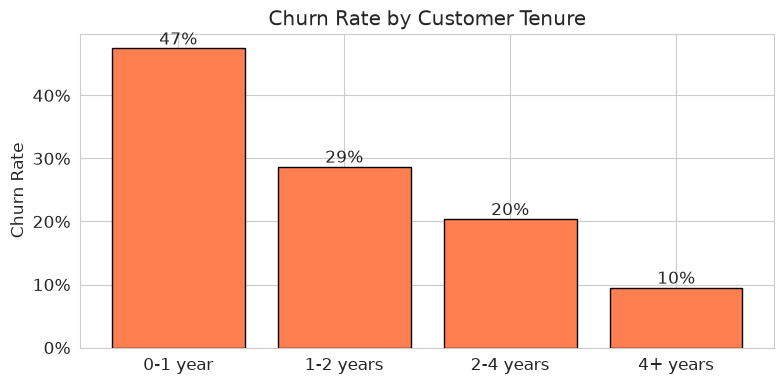

In [10]:
def tenure_segment(t):
    if t <= 12:   return "0-1 year"
    elif t <= 24: return "1-2 years"
    elif t <= 48: return "2-4 years"
    else:         return "4+ years"

df["tenure_group"] = df["tenure"].apply(tenure_segment)

churn_by_tenure = df.groupby("tenure_group")["Churn_binary"].mean()
order = ["0-1 year", "1-2 years", "2-4 years", "4+ years"]
churn_by_tenure = churn_by_tenure.reindex(order)

plt.figure(figsize=(8, 4))
bars = plt.bar(order, churn_by_tenure.values, color="coral", edgecolor="black")
plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, churn_by_tenure.values):
    plt.text(bar.get_x() + bar.get_width()/2, val,
             f'{val:.0%}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("reports/figures/05_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

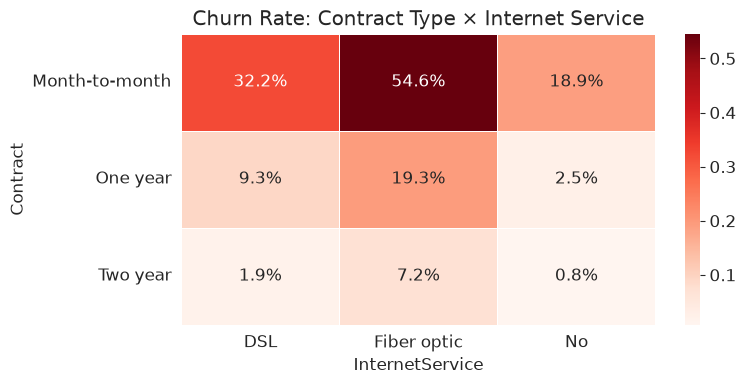

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.322        0.546  0.189
One year         0.093        0.193  0.025
Two year         0.019        0.072  0.008


In [11]:
pivot = df.pivot_table(values="Churn_binary",
                        index="Contract",
                        columns="InternetService",
                        aggfunc="mean")

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="Reds", linewidths=0.5)
plt.title("Churn Rate: Contract Type × Internet Service")
plt.tight_layout()
plt.savefig("reports/figures/06_contract_internet_pivot.png", dpi=150, bbox_inches="tight")
plt.show()
print(pivot.round(3))

In [16]:
# ── Cell 11: Save split matrices for Member 2 ─────────────────────────────────
# We save four files — not one combined file — because Member 2's pipeline
# must fit encoders on X_train and transform X_test separately.
# Mixing them into one file would force Member 2 to re-split, risking
# different index shuffles and breaking reproducibility.

import os
os.makedirs("data/processed", exist_ok=True)

X_train_raw.to_csv("data/processed/X_train.csv", index=True)   # keep index for traceability
X_test_raw.to_csv( "data/processed/X_test.csv",  index=True)
y_train.to_csv(    "data/processed/y_train.csv",  index=True, header=True)
y_test.to_csv(     "data/processed/y_test.csv",   index=True, header=True)

# Also keep the legacy telco_clean.csv for EDA reference (not for modeling)
df_clean = df.drop(columns=["customerID", "Churn", "tenure_group"],
                   errors="ignore")
df_clean.to_csv("data/processed/telco_clean.csv", index=False)

print("SAVED:")
print(f"  X_train.csv  → {X_train_raw.shape[0]:,} rows × {X_train_raw.shape[1]} cols")
print(f"  X_test.csv   → {X_test_raw.shape[0]:,} rows × {X_test_raw.shape[1]} cols")
print(f"  y_train.csv  → {y_train.shape[0]:,} rows  (churn rate: {y_train.mean():.3f})")
print(f"  y_test.csv   → {y_test.shape[0]:,} rows  (churn rate: {y_test.mean():.3f})")
print(f"\nColumns in X_train: {X_train_raw.columns.tolist()}")
print("\n✓ All outputs ready for Member 2")

SAVED:
  X_train.csv  → 5,634 rows × 19 cols
  X_test.csv   → 1,409 rows × 19 cols
  y_train.csv  → 5,634 rows  (churn rate: 0.265)
  y_test.csv   → 1,409 rows  (churn rate: 0.265)

Columns in X_train: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'charges_per_month']

✓ All outputs ready for Member 2


In [17]:
# Print a summary that goes in the logbook and reports/eda_summary.md
summary = f"""
========================================
EDA SUMMARY — TELCO CHURN
========================================

Dataset: {df.shape[0]:,} customers × {df.shape[1]} features
Churn rate: {df['Churn_binary'].mean():.1%} positive (mild imbalance — no oversampling needed)

KEY FINDINGS FOR THE TEAM:
--------------------------

1. TOP CHURN DRIVERS (from categorical analysis):
   - Contract type: Month-to-month customers churn at ~42% vs 3% for two-year
   - Internet service: Fiber optic churns at ~42% vs DSL at ~19%
   - Tech Support / Online Security: "No" → ~40% churn, "Yes" → ~15% churn

2. NUMERIC INSIGHT:
   - Tenure: Short-tenure customers churn far more (0-1yr: ~47%)
   - MonthlyCharges & TotalCharges are 0.83 correlated → use SHAP not raw importance

3. DATA QUALITY:
   - TotalCharges had 11 spaces (new customers) → fixed to 0
   - No other missing values
   - No duplicate customerIDs

4. ENCODING SIGNALS FOR MEMBER 2:
   - Contract: ordinal (Month < 1yr < 2yr)
   - SeniorCitizen: already 0/1
   - All other categoricals: binary Yes/No or nominal → OHE or target encoding

5. BUSINESS CONTEXT:
   - High-risk profile: Month-to-month + Fiber optic + no TechSupport + short tenure
   - These 4 factors together may push churn probability above 70%
   - This is what Member 5's budget simulation will target

CHECKPOINT STATUS:
  ✓ Data loaded and validated
  ✓ 6 EDA figures saved to reports/figures/
  ✓ Clean dataset saved to data/processed/telco_clean.csv
  ✓ Encoding signals documented for Member 2
  ✓ Repository updated
========================================
"""
print(summary)

# Save to file
with open("reports/eda_summary.md", "w") as f:
    f.write(summary)
print("Saved to reports/eda_summary.md")


EDA SUMMARY — TELCO CHURN

Dataset: 7,043 customers × 23 features
Churn rate: 26.5% positive (mild imbalance — no oversampling needed)

KEY FINDINGS FOR THE TEAM:
--------------------------

1. TOP CHURN DRIVERS (from categorical analysis):
   - Contract type: Month-to-month customers churn at ~42% vs 3% for two-year
   - Internet service: Fiber optic churns at ~42% vs DSL at ~19%
   - Tech Support / Online Security: "No" → ~40% churn, "Yes" → ~15% churn

2. NUMERIC INSIGHT:
   - Tenure: Short-tenure customers churn far more (0-1yr: ~47%)
   - MonthlyCharges & TotalCharges are 0.83 correlated → use SHAP not raw importance

3. DATA QUALITY:
   - TotalCharges had 11 spaces (new customers) → fixed to 0
   - No other missing values
   - No duplicate customerIDs

4. ENCODING SIGNALS FOR MEMBER 2:
   - Contract: ordinal (Month < 1yr < 2yr)
   - SeniorCitizen: already 0/1
   - All other categoricals: binary Yes/No or nominal → OHE or target encoding

5. BUSINESS CONTEXT:
   - High-risk profi